# Task 5 (Advanced) - Netflix Trend Forecasting Model
**Auspify Technologies - Machine Learning Internship**

Forecasts future Netflix content release trends (number of titles added per
month) based on historical `date_added` data.

Workflow:

  Step 1: Prepare time-based features.
  
  Step 2: Analyze historical release patterns.
  
  Step 3: Build forecasting models.
  
  Step 4: Generate future predictions.
  
  Step 5: Evaluate forecasting accuracy.

In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

DATA_PATH = "Dataset.csv"
FORECAST_HORIZON = 6
OUTPUT_PLOT = "forecast_trend.png"



# Step 1: Prepare time-based features
def prepare_time_series(path):
    """
    Step 1: Create a monthly time series of Netflix titles added.
    The partial trailing month is removed to avoid using incomplete data.
    """
    df = pd.read_csv(path)

    df["date_added"] = pd.to_datetime(
        df["date_added"],
        errors="coerce"
    )

    df = df.dropna(subset=["date_added"])

    # Monthly count of titles added
    monthly_counts = (
        df.set_index("date_added")
        .resample("MS")
        .size()
    )

    # Keep the relevant historical period
    monthly_counts = monthly_counts[
        monthly_counts.index >= "2015-01-01"
    ]

    # Detect and remove an incomplete final month
    max_date_in_data = df["date_added"].max()
    cutoff = max_date_in_data.replace(day=1)

    if max_date_in_data.day < 28:
        print(
            f"Dropping partial trailing month "
            f"{cutoff.strftime('%Y-%m')} "
            f"(data only goes up to {max_date_in_data.date()})"
        )

        monthly_counts = monthly_counts[
            monthly_counts.index < cutoff
        ]

    return monthly_counts


# Step 2: Analyze historical release patterns
def analyze_patterns(series):
    """Step 2: Analyze historical release volume and seasonality."""

    print(
        f"Date range: "
        f"{series.index.min().date()} -> "
        f"{series.index.max().date()}"
    )

    print(
        f"Average titles added per month: "
        f"{series.mean():.1f}"
    )

    print(
        f"Peak month: "
        f"{series.idxmax().date()} "
        f"({series.max()} titles)"
    )

    print(
        "\nAverage titles added by calendar month "
        "(seasonality check):"
    )

    print(
        series.groupby(
            series.index.month
        ).mean().round(1)
    )


# Step 3: Build forecasting models
def train_test_split_series(series, test_size=6):
    """
    Split the time series chronologically.
    The last test_size months are held out for evaluation.
    """
    train = series.iloc[:-test_size]
    test = series.iloc[-test_size:]

    return train, test


def build_linear_trend_model(train):
    """Build a simple linear trend forecasting model."""

    X = np.arange(len(train)).reshape(-1, 1)
    y = train.values

    model = LinearRegression()
    model.fit(X, y)

    return model


def holt_winters_additive(
    series_values,
    season_len=12,
    alpha=0.3,
    beta=0.1,
    gamma=0.2,
    steps=6
):
    """
    Dependency-free additive Holt-Winters forecasting.

    The smoothing parameters are fixed rather than estimated
    automatically.
    """

    y = np.asarray(
        series_values,
        dtype=float
    )

    n = len(y)

    # Initial seasonal averages
    season_avgs = [
        y[i:i + season_len].mean()
        for i in range(
            0,
            2 * season_len,
            season_len
        )
    ]

    level = season_avgs[0]

    trend = (
        season_avgs[1] - season_avgs[0]
    ) / season_len

    # Initial seasonal components
    seasonal = [
        y[i] - season_avgs[i // season_len]
        for i in range(2 * season_len)
    ]

    seasonal = [
        np.mean([
            seasonal[i],
            seasonal[i + season_len]
        ])
        for i in range(season_len)
    ]

    seasonals = list(seasonal)

    # Update level, trend and seasonal components
    for t in range(n):

        if t < len(seasonals):
            seas = seasonals[t]
        else:
            seas = seasonals[t - season_len]

        previous_level = level

        level = (
            alpha * (y[t] - seas)
            + (1 - alpha)
            * (previous_level + trend)
        )

        trend = (
            beta * (level - previous_level)
            + (1 - beta) * trend
        )

        updated_season = (
            gamma * (y[t] - level)
            + (1 - gamma) * seas
        )

        seasonals.append(updated_season)

    # Generate future forecasts
    forecasts = []

    for h in range(1, steps + 1):

        seas = seasonals[
            n - season_len
            + ((h - 1) % season_len)
        ]

        forecast = (
            level
            + h * trend
            + seas
        )

        forecasts.append(forecast)

    return np.array(forecasts)


# Step 4: Generate predictions
def forecast_linear(model, train_len, steps):
    """Generate future predictions using the linear trend model."""

    X_future = np.arange(
        train_len,
        train_len + steps
    ).reshape(-1, 1)

    return model.predict(X_future)


# Step 5: Evaluate forecasting accuracy
def evaluate_forecast(name, actual, predicted):
    """Calculate MAE and RMSE for a forecasting model."""

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = mean_squared_error(
        actual,
        predicted
    ) ** 0.5

    print(
        f"{name:20s} -> "
        f"MAE: {mae:.2f}, "
        f"RMSE: {rmse:.2f}"
    )

    return mae, rmse

## Step 1: Prepare time-based features

In [2]:
print("Step 1: Preparing monthly time-based features...")
series = prepare_time_series(DATA_PATH)
print(
    f"-> {len(series)} monthly data points"
)


Step 1: Preparing monthly time-based features...
Dropping partial trailing month 2021-09 (data only goes up to 2021-09-25)
-> 80 monthly data points


## Step 2: Analyze historical release patterns

In [3]:
print(
    "\nStep 2: Analyzing historical release patterns..."
)

analyze_patterns(series)


Step 2: Analyzing historical release patterns...
Date range: 2015-01-01 -> 2021-08-01
Average titles added per month: 106.9
Peak month: 2021-07-01 (257 titles)

Average titles added by calendar month (seasonality check):
date_added
1     104.9
2      79.7
3     105.7
4     108.7
5      90.0
6     103.9
7     118.0
8     107.4
9      97.0
10    123.7
11    116.0
12    133.8
dtype: float64


## Step 3: Build forecasting models (train/test split, last 6 months held out)

In [4]:
print(
    "\nStep 3: Building forecasting models "
    "(last 6 months held out)..."
)

train, test = train_test_split_series(
    series,
    test_size=FORECAST_HORIZON
)

linear_model = build_linear_trend_model(
    train
)

print(
    f"Train months: {len(train)}, "
    f"Test months: {len(test)}"
)



Step 3: Building forecasting models (last 6 months held out)...
Train months: 74, Test months: 6


## Step 4: Generate predictions on the held-out test months

In [5]:
print(
    "\nStep 4: Generating predictions "
    "on the held-out test months..."
)

linear_preds = forecast_linear(
    linear_model,
    len(train),
    FORECAST_HORIZON
)

hw_preds = holt_winters_additive(
    train.values,
    season_len=12,
    steps=FORECAST_HORIZON
)



Step 4: Generating predictions on the held-out test months...


## Step 5: Evaluate forecasting accuracy

In [6]:
print(
    "\nStep 5: Evaluating forecasting accuracy..."
)

evaluate_forecast(
    "Linear Trend",
    test.values,
    linear_preds
)

evaluate_forecast(
    "Holt-Winters",
    test.values,
    hw_preds
)

# Naive baseline: average of the previous 12 months
naive_pred = [
    train.iloc[-12:].mean()
] * FORECAST_HORIZON

evaluate_forecast(
    "Naive (12-mo avg)",
    test.values,
    naive_pred
)


Step 5: Evaluating forecasting accuracy...
Linear Trend         -> MAE: 43.40, RMSE: 53.05
Holt-Winters         -> MAE: 68.55, RMSE: 79.08
Naive (12-mo avg)    -> MAE: 47.64, RMSE: 55.77


(47.63888888888888, 55.77490724131935)

## Genuine future forecast (refit on full history) & plot

In [9]:
print(
    "\nGenerating genuine future forecasts "
    "using the full historical dataset..."
)

# Refit the linear model using all available observations
full_linear = build_linear_trend_model(
    series
)

future_linear = forecast_linear(
    full_linear,
    len(series),
    FORECAST_HORIZON
)

# Fit Holt-Winters using all available observations
future_hw = holt_winters_additive(
    series.values,
    season_len=12,
    steps=FORECAST_HORIZON
)



# Create future dates
future_index = pd.date_range(
    series.index[-1]
    + pd.offsets.MonthBegin(1),
    periods=FORECAST_HORIZON,
    freq="MS"
)

# Display future forecasts
forecast_df = pd.DataFrame(
    {
        "Linear Trend": future_linear.round(1),
        "Holt-Winters": future_hw.round(1)
    },
    index=future_index
)

print(
    f"\nForecast for the next "
    f"{FORECAST_HORIZON} months:"
)

print(forecast_df)


Generating genuine future forecasts using the full historical dataset...

Forecast for the next 6 months:
            Linear Trend  Holt-Winters
2021-09-01         208.6         196.0
2021-10-01         211.1         224.6
2021-11-01         213.6         219.5
2021-12-01         216.1         242.6
2022-01-01         218.6         224.8
2022-02-01         221.1         202.3


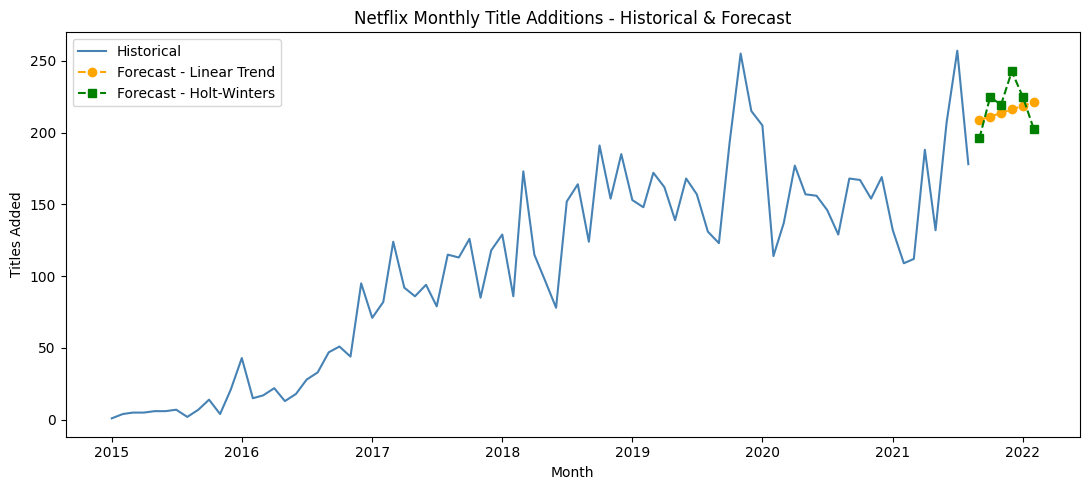


Saved forecast plot to forecast_trend.png


In [10]:
# Visualization
plt.figure(figsize=(11, 5))

plt.plot(
    series.index,
    series.values,
    label="Historical",
    color="steelblue"
)

plt.plot(
    future_index,
    future_linear,
    label="Forecast - Linear Trend",
    color="orange",
    linestyle="--",
    marker="o"
)

plt.plot(
    future_index,
    future_hw,
    label="Forecast - Holt-Winters",
    color="green",
    linestyle="--",
    marker="s"
)

plt.title(
    "Netflix Monthly Title Additions - "
    "Historical & Forecast"
)

plt.xlabel("Month")
plt.ylabel("Titles Added")

plt.legend()

plt.tight_layout()

plt.savefig(
    OUTPUT_PLOT,
    dpi=120
)

plt.show()

print(
    f"\nSaved forecast plot to {OUTPUT_PLOT}"
)

## Conclusion

### Executive Summary
To assist content acquisition strategy, we modeled the monthly volume of new titles added to Netflix between 2015 and 2021 and built a 6-month forecasting model.

### Key Evaluation Results (Held-Out Test Set: 6 Months)
| Model | MAE | RMSE | Status |
| :--- | :---: | :---: | :--- |
| **Linear Trend** | **43.40** | **53.05** | **Selected Model** |
| Naive Baseline (12-mo Avg) | 47.64 | 55.77 | Benchmark |
| Holt-Winters (Additive) | 68.55 | 79.08 | Secondary Reference |

### 6-Month Ahead Forecast Summary
Using the primary Linear Trend model refit on the full historical data, Netflix is projected to add approximately **208 to 221 titles per month** over the next six months.